# Phase 1: GameScope Data Visualization

The point of this phase is to understand the structure of the data available to us via Twitch’s Internet Game Database (IGDB). By understanding the data better, we can gain insights into the best way to leverage it to provide predictive recommendations and data-driven insights. This includes exploring the schema, relationships between entities (games, genres, platforms, companies, and themes), and evaluating data quality and coverage. The findings from this phase will directly inform feature selection, data modeling decisions, and visualization strategies used in later phases of the recommendation system and greater application

## IGDB Data Collected

We pulled in data from the IGDB database using a script written in go. The schema of the records is added below:

```go
type Game struct {		// need to change these maybe?
	ID                 int     `json:"id"`
	Name               string  `json:"name"`
	FirstReleaseDate   int64   `json:"first_release_date"`
	Genres             []int   `json:"genres"`
	Platforms          []int   `json:"platforms"`
	Themes             []int   `json:"themes"`
	Rating             float64 `json:"rating"`
	RatingCount        int     `json:"rating_count"`
	TotalRating        float64 `json:"total_rating"`
	TotalRatingCount   int     `json:"total_rating_count"`
	Summary            string  `json:"summary"`
	Storyline          string  `json:"storyline"`
}
```

In [3]:
# Import Libraries
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import os

In [4]:
def load_data(filename):
    # Load CSV
    df = pd.read_csv(filename)

    # Columns that contain comma-separated integers
    list_cols = ["genres", "platforms", "themes"]

    # Convert comma-separated strings to lists, empty string -> empty list
    for col in list_cols:
        df[col] = (
            df[col]
            .fillna("")  # handle empty cells
            .apply(lambda x: [int(v) for v in x.split(",")] if x else [])
        )

    # Replace empty strings in other columns with NA
    df = df.replace("", pd.NA)

    # Treat 0 as missing in rating columns
    rating_cols = [
        "rating",
        "rating_count",
        "total_rating",
        "total_rating_count"
    ]
    for col in rating_cols:
        df.loc[df[col] == 0, col] = pd.NA

    return df, list_cols, rating_cols

# Load and preprocess
df, list_cols, rating_cols = load_data("../data_collection/out/igdb_games_all.csv")

### Understanding Data Integrity

We want to know where the data has null values

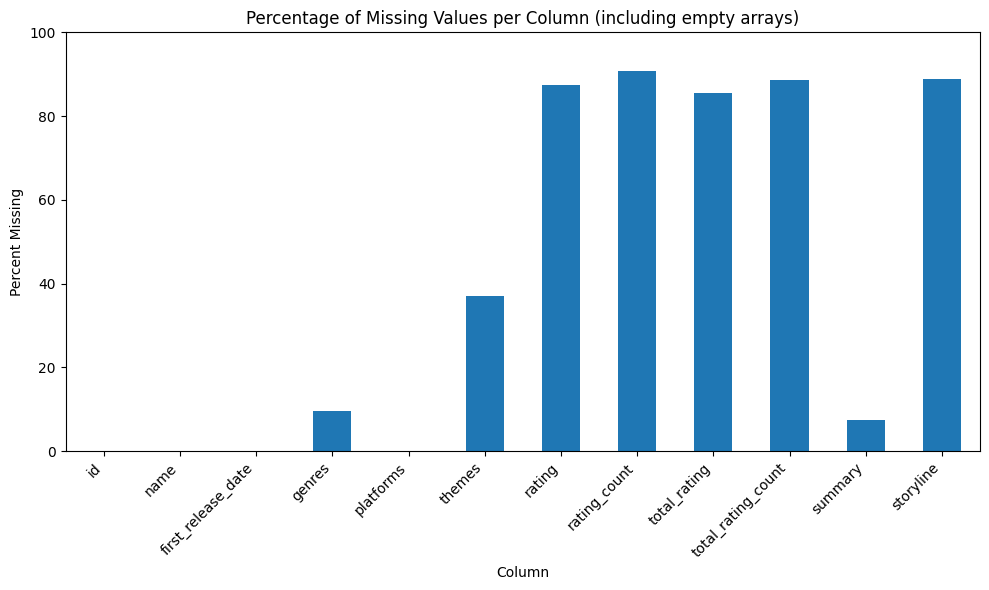

In [5]:
# Compute missing percentages
null_pct = {}
for col in df.columns:
    if col in list_cols:
        # Consider empty lists as missing
        null_pct[col] = df[col].apply(lambda x: len(x) == 0).mean() * 100
    else:
        null_pct[col] = df[col].isna().mean() * 100

# Convert to Series for plotting
null_pct = pd.Series(null_pct)

# Plot missing percentages
plt.figure(figsize=(10, 6))
null_pct.plot(kind="bar")
plt.title("Percentage of Missing Values per Column (including empty arrays)")
plt.ylabel("Percent Missing")
plt.xlabel("Column")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Data Columns

Investigating the specific columns and what that data looks like

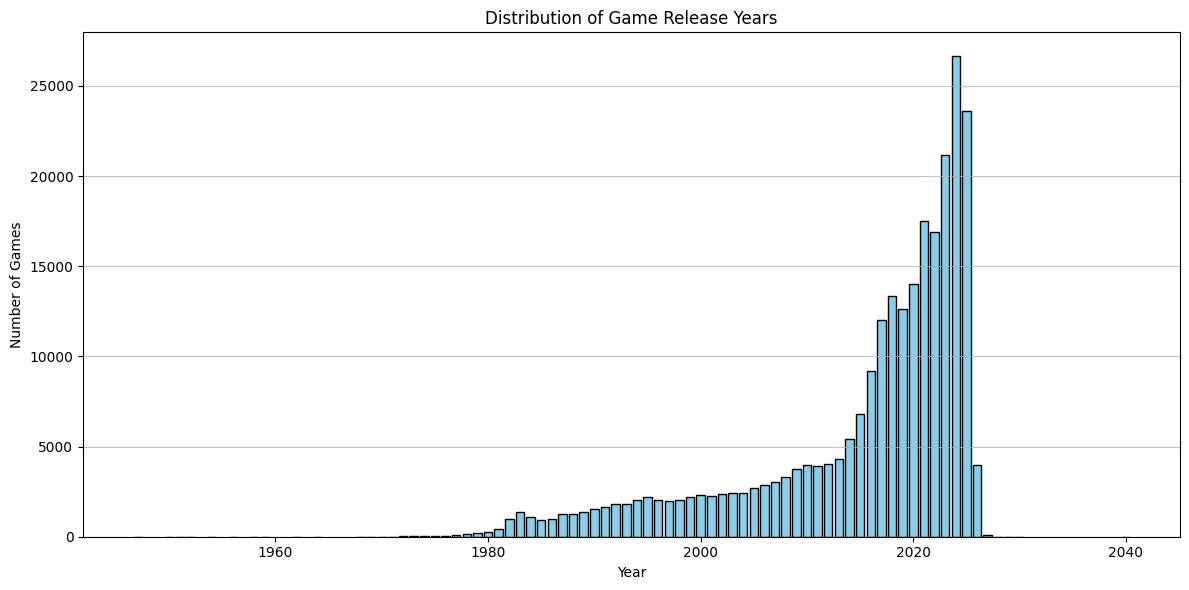

In [6]:
'''
Plot distribution of game release years
'''

# Convert to datetime
df['first_release_date'] = pd.to_datetime(df['first_release_date'], errors='coerce')
df = df.dropna(subset=['first_release_date'])

# Extract year
df['release_year'] = df['first_release_date'].dt.year

# Count games per year
year_counts = df['release_year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Game Release Years')
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

/tmp/ipykernel_62047/3581071759.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")


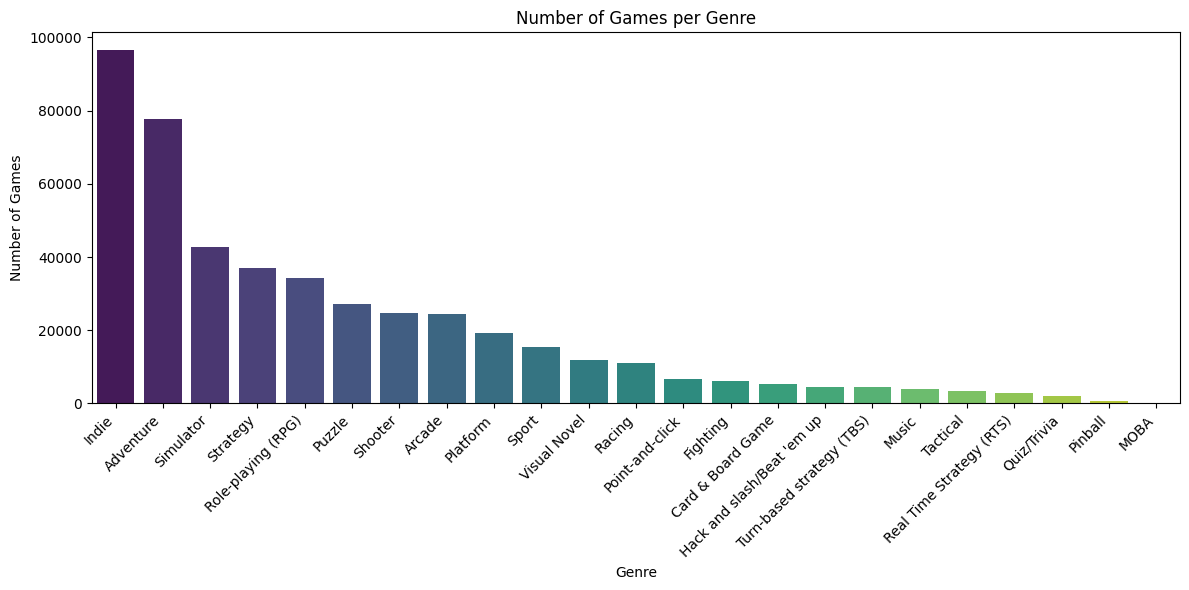

In [7]:
'''
Plot distribution of genres
'''
def fetch_igdb_genres():
    load_dotenv('../.env')

    client_id = os.getenv("IGDB_CLIENT_ID")
    client_secret = os.getenv("IGDB_CLIENT_SECRET")

    token_resp = requests.post(
        "https://id.twitch.tv/oauth2/token",
        params={
            "client_id": client_id,
            "client_secret": client_secret,
            "grant_type": "client_credentials",
        }
    ).json()

    token = token_resp["access_token"]

    query = "fields id, name; limit 500;"

    resp = requests.post(
        "https://api.igdb.com/v4/genres",
        data=query,
        headers={
            "Client-ID": client_id,
            "Authorization": f"Bearer {token}",
        }
    )

    genres = resp.json()
    return {g["id"]: g["name"] for g in genres}

def map_genre_names(df, genre_map):
    df = df.copy()
    df["genre_names"] = df["genres"].apply(
        lambda lst: [genre_map.get(g, f"Unknown({g})") for g in lst]
    )
    return df

def plot_genre_histogram(df):
    # Ensure genre names are mapped
    genre_map = fetch_igdb_genres()
    df = map_genre_names(df, genre_map)

    # Flatten list of genres to a single series
    all_genres = [g for sublist in df["genre_names"] for g in sublist]

    # Count frequency of each genre
    genre_counts = pd.Series(all_genres).value_counts().sort_values(ascending=False)

    # Plot
    plt.figure(figsize=(12, 6))
    sns.barplot(x=genre_counts.index, y=genre_counts.values, palette="viridis")
    plt.title("Number of Games per Genre")
    plt.xlabel("Genre")
    plt.ylabel("Number of Games")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_genre_histogram(df)

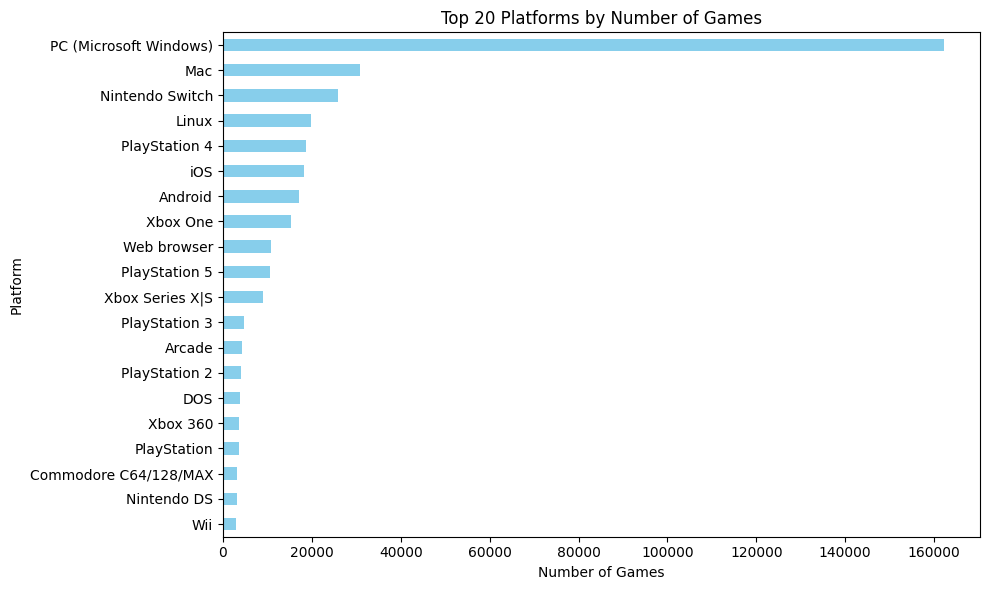

In [8]:
'''
Plot distribution of platform
'''
def fetch_igdb_platforms():
    """Fetch IGDB platform data (id -> name mapping)."""
    load_dotenv('../.env')
    client_id = os.getenv("IGDB_CLIENT_ID")
    client_secret = os.getenv("IGDB_CLIENT_SECRET")

    # Get access token
    token_resp = requests.post(
        "https://id.twitch.tv/oauth2/token",
        params={
            "client_id": client_id,
            "client_secret": client_secret,
            "grant_type": "client_credentials",
        }
    ).json()

    token = token_resp["access_token"]

    query = "fields id, name; limit 500;"

    resp = requests.post(
        "https://api.igdb.com/v4/platforms",
        data=query,
        headers={
            "Client-ID": client_id,
            "Authorization": f"Bearer {token}",
        }
    )

    platforms = resp.json()
    return {p["id"]: p["name"] for p in platforms}


def map_platform_names(df, platform_map):
    """Map platform IDs in dataframe to readable names."""
    df = df.copy()
    df["platform_names"] = df["platforms"].apply(
        lambda lst: [platform_map.get(p, f"Unknown({p})") for p in lst]
    )
    return df


def plot_platform_histogram(df, top_n=20):
    # Fetch platform names from IGDB and map IDs
    platform_map = fetch_igdb_platforms()
    df = map_platform_names(df, platform_map)

    # Flatten list of platforms
    all_platforms = [p for sublist in df["platform_names"] for p in sublist]

    # Count frequency
    platform_counts = pd.Series(all_platforms).value_counts()

    # Keep top n
    platform_counts = platform_counts.head(top_n).sort_values()  # sort ascending for horizontal bars

    # Plot horizontal bar chart
    plt.figure(figsize=(10, 6))
    platform_counts.plot(kind="barh", color="skyblue")
    plt.title(f"Top {top_n} Platforms by Number of Games")
    plt.xlabel("Number of Games")
    plt.ylabel("Platform")
    plt.tight_layout()
    plt.show()

plot_platform_histogram(df)


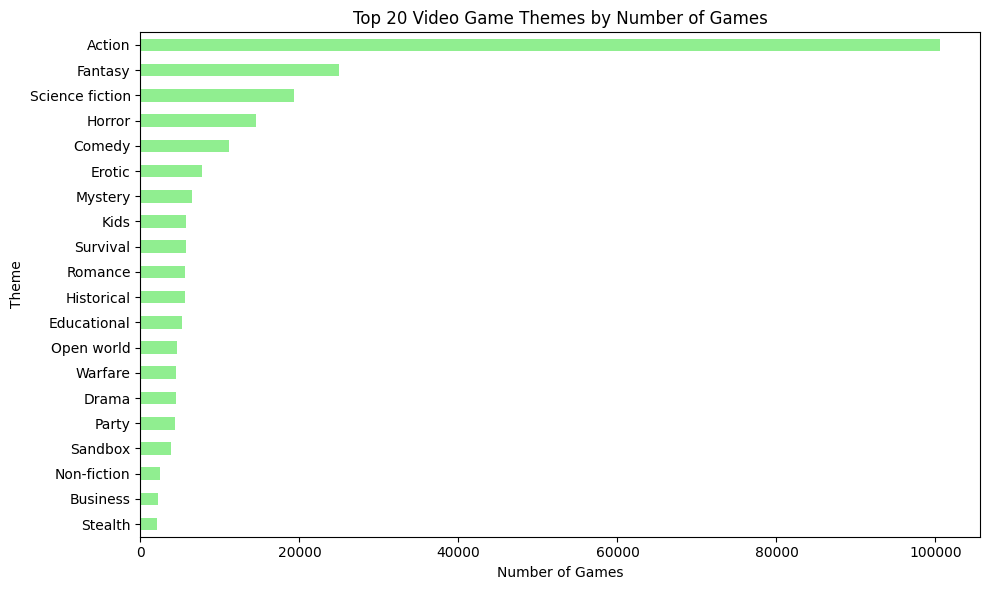

In [9]:
'''
Plot distribution of themes
'''
def fetch_igdb_themes(limit=500):
    """Fetch IGDB theme data (id -> name mapping)."""
    load_dotenv('../.env')
    client_id = os.getenv("IGDB_CLIENT_ID")
    client_secret = os.getenv("IGDB_CLIENT_SECRET")

    # Get access token
    token_resp = requests.post(
        "https://id.twitch.tv/oauth2/token",
        params={
            "client_id": client_id,
            "client_secret": client_secret,
            "grant_type": "client_credentials",
        }
    ).json()

    token = token_resp["access_token"]

    query = f"fields id, name; limit {limit};"

    resp = requests.post(
        "https://api.igdb.com/v4/themes",
        data=query,
        headers={
            "Client-ID": client_id,
            "Authorization": f"Bearer {token}",
        }
    )

    themes = resp.json()
    return {t["id"]: t["name"] for t in themes}


def map_theme_names(df, theme_map):
    """Map theme IDs in dataframe to readable names."""
    df = df.copy()
    df["theme_names"] = df["themes"].apply(
        lambda lst: [theme_map.get(t, f"Unknown({t})") for t in lst]
    )
    return df


def plot_theme_histogram(df, top_n=20):
    # Fetch theme names from IGDB and map IDs
    theme_map = fetch_igdb_themes()
    df = map_theme_names(df, theme_map)

    # Flatten list of themes
    all_themes = [t for sublist in df["theme_names"] for t in sublist]

    # Count frequency
    theme_counts = pd.Series(all_themes).value_counts()

    # Keep top N
    theme_counts = theme_counts.head(top_n).sort_values()  # sort ascending for horizontal bars

    # Plot horizontal bar chart
    plt.figure(figsize=(10, 6))
    theme_counts.plot(kind="barh", color="lightgreen")
    plt.title(f"Top {top_n} Video Game Themes by Number of Games")
    plt.xlabel("Number of Games")
    plt.ylabel("Theme")
    plt.tight_layout()
    plt.show()

plot_theme_histogram(df)


### Exploring Relationships

We will now explore relationships between columns

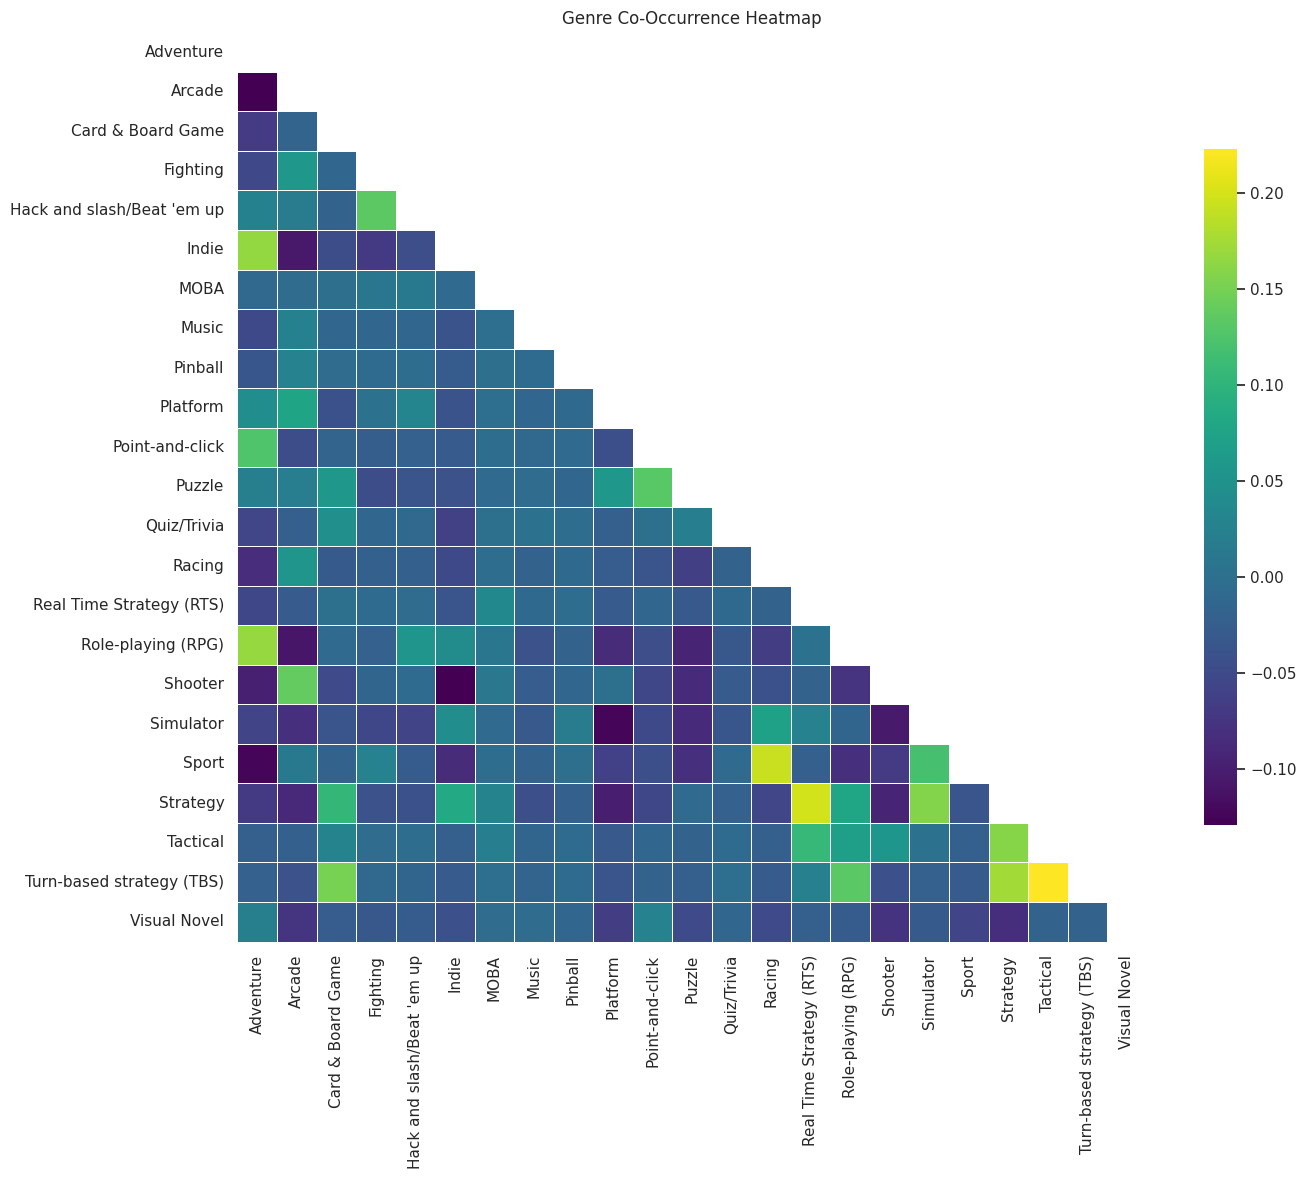

In [10]:
'''
Plot heatmap of genre co-occurrence
'''
def genre_heatmap(df):
    # Ensure genre names are mapped - implemented previously
    genre_map = fetch_igdb_genres()
    df = map_genre_names(df, genre_map)

    df = df[df["genre_names"].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    all_genres = sorted({g for sub in df["genre_names"] for g in sub})
    genre_matrix = pd.DataFrame(0, index=df.index, columns=all_genres)

    for idx, genre_list in df["genre_names"].items():
        genre_matrix.loc[idx, genre_list] = 1

    corr = genre_matrix.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.set_theme(style="white")
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr,
        mask=mask,
        cmap="viridis",
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.7},
    )
    plt.title("Genre Co‑Occurrence Heatmap")
    plt.tight_layout()
    plt.show()

genre_heatmap(df)


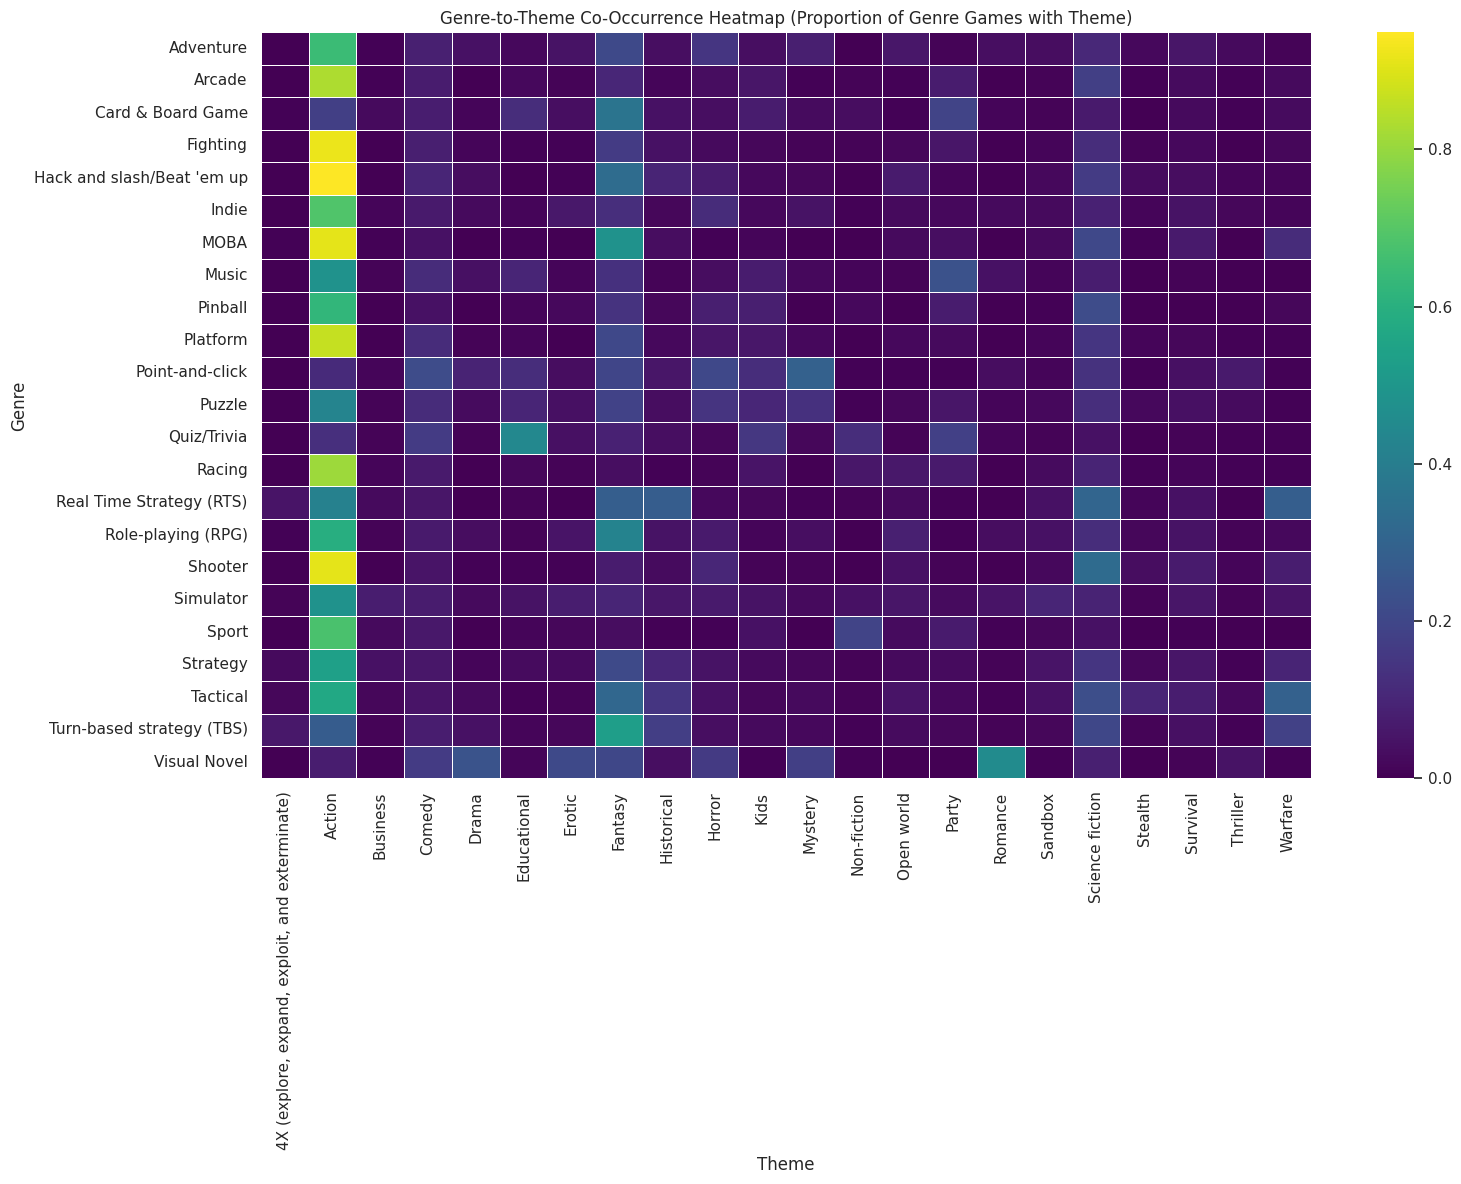

In [11]:
# Convert comma-separated IDs to lists
list_cols = ["genres", "themes"]

# Ensure genres/themes are lists of ints
list_cols = ["genres", "themes"]
for col in list_cols:
    def to_list(x):
        if isinstance(x, list):
            return x  # already a list
        elif pd.isna(x) or x == "":
            return []
        else:
            return [int(v) for v in x.split(",")]
    df[col] = df[col].apply(to_list)

# --- Map genres and themes ---
genre_map = fetch_igdb_genres()
theme_map = fetch_igdb_themes()

df["genre_names"] = df["genres"].apply(lambda lst: [genre_map.get(g, f"Unknown({g})") for g in lst])
df["theme_names"] = df["themes"].apply(lambda lst: [theme_map.get(t, f"Unknown({t})") for t in lst])

# --- Filter out empty ---
df = df[df["genre_names"].apply(len) > 0]
df = df[df["theme_names"].apply(len) > 0]

# --- Binary matrices ---
all_genres = sorted({g for sub in df["genre_names"] for g in sub})
all_themes = sorted({t for sub in df["theme_names"] for t in sub})

genre_matrix = pd.DataFrame(0, index=df.index, columns=all_genres)
theme_matrix = pd.DataFrame(0, index=df.index, columns=all_themes)

for idx, g_list in df["genre_names"].items():
    genre_matrix.loc[idx, g_list] = 1

for idx, t_list in df["theme_names"].items():
    theme_matrix.loc[idx, t_list] = 1

# --- Compute genre-theme correlation ---
# This is equivalent to the Pearson correlation between binary columns
corr = genre_matrix.T.corrwith(theme_matrix.T, axis=1)  # won't work directly
# Instead, we can compute co-occurrence ratio matrix
cooccurrence = genre_matrix.T.dot(theme_matrix)  # genres x themes: number of games with both
cooccurrence_ratio = cooccurrence.div(genre_matrix.sum(axis=0), axis=0)  # normalize by genre count

# --- Plot heatmap ---
plt.figure(figsize=(16, 12))
sns.heatmap(cooccurrence_ratio, cmap="viridis", linewidths=0.5)
plt.title("Genre-to-Theme Co-Occurrence Heatmap (Proportion of Genre Games with Theme)")
plt.xlabel("Theme")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


### Investigating the `summary` column and its relationship to other fields

An earlier visualization reveled that the `summary` column had a relatively low "missing data" percent as opposed to the `storyline` column. We want to see how this can be leveraged with other fields to give each game record more "context." Hopefully this will reveal some insights into how we can use the `summary` to predict a user's affinity to certain games they have not played yet.

In [12]:
%pip install nltk
%pip install sentence-transformers
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


#### Text Processing
We clean and normalize game summaries to remove punctuation, special characters, extra whitespace, and capitalization differences. This ensures that semantically similar summaries produce similar embeddings, improving the quality of downstream analysis like clustering, t-SNE visualization, and similarity-based recommendations.

In [13]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

def clean_summary(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return " ".join([w for w in text.split() if w not in stopwords.words('english')])

df['clean_summary'] = df['summary'].apply(clean_summary)


[nltk_data] Downloading package stopwords to /home/joseph/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Generate Embeddings
We use Sentence-BERT to convert cleaned game summaries into dense vectors, capturing the game’s semantic meaning beyond just genres or tags. These embeddings are used for clustering, visualization, and similarity-based recommendations.

Check out the [SentenceTransformers Documentation](https://sbert.net/)

In [14]:
from sentence_transformers import SentenceTransformer

# Load pre-trained Sentence-BERT model
model = SentenceTransformer('all-MiniLM-L6-v2')
summary_embeddings = model.encode(df['clean_summary'].tolist())

# Save for reuse
np.save("summary_embeddings.npy", summary_embeddings)


/home/joseph/GameScope/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Encode Metadata
We convert genres and themes into binary vectors and combine them with the summary embeddings to create the final feature matrix for clustering, visualization, and recommendations.

Check out [`sklearn.preprocessing.MultiLabelBinarizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html)

In [15]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler

mlb_genres = MultiLabelBinarizer()
genre_features = mlb_genres.fit_transform(df['genre_names'])

mlb_themes = MultiLabelBinarizer()
theme_features = mlb_themes.fit_transform(df['theme_names'])

# Combine embeddings + metadata
X = np.hstack([summary_embeddings, genre_features, theme_features])
print("Feature matrix shape:", X.shape)

Feature matrix shape: (154888, 429)


#### Visualize Game Clusters (PCA)
We reduce the high-dimensional feature matrix to 2D with PCA to explore overall patterns and clusters among games.

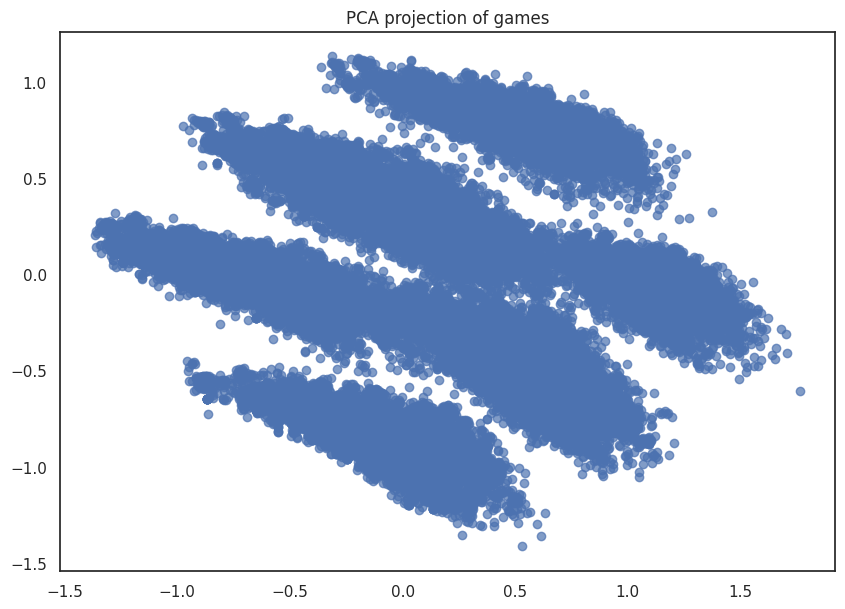

In [16]:
from sklearn.decomposition import PCA

# X = embeddings + metadata
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.7)
plt.title("PCA projection of games")
plt.show()

#### Cluster the 2D PCA projections
We apply KMeans to the 2D PCA coordinates to group games into clusters and explore common patterns among them.

In [17]:
from sklearn.cluster import KMeans

# Run KMeans on the PCA coordinates
kmeans = KMeans(n_clusters=4, random_state=42)
df['pca_cluster'] = kmeans.fit_predict(X_2d)

# Quick check
df['pca_cluster'].value_counts()


pca_cluster
2    48818
3    38352
1    36960
0    30758
Name: count, dtype: int64

#### Compare Clusters by Metadata
We summarize each PCA cluster by counting the most common genres and themes, calcuating average ratings, and showing sample games to interpret what each cluster represents.

In [18]:
from collections import Counter

for cluster in range(4):
    subset = df[df['pca_cluster']==cluster]
    
    # Top genres
    all_genres = [g for sublist in subset['genre_names'] for g in sublist]
    top_genres = Counter(all_genres).most_common(5)
    
    # Top themes
    all_themes = [t for sublist in subset['theme_names'] for t in sublist]
    top_themes = Counter(all_themes).most_common(5)
    
    print(f"Cluster {cluster}:")
    print("  Top Genres:", top_genres)
    print("  Top Themes:", top_themes)
    print("  Avg Rating:", subset['rating'].mean())
    print("  Avg Rating Count:", subset['rating_count'].mean())
    print("  Sample Games:", subset['name'].sample(5).tolist())
    print()


Cluster 0:
  Top Genres: [('Adventure', 30602), ('Indie', 28121), ('Role-playing (RPG)', 10176), ('Simulator', 5697), ('Strategy', 4918)]
  Top Themes: [('Action', 21809), ('Fantasy', 6758), ('Horror', 4973), ('Mystery', 2363), ('Comedy', 2069)]
  Avg Rating: 67.25277089035582
  Avg Rating Count: 45.85377564382366
  Sample Games: ['Ratcheteer DX', 'No Players Online Classic', 'Pirates of Black Cove', 'Versus Go', 'Blood Harvest 3']

Cluster 1:
  Top Genres: [('Shooter', 14537), ('Arcade', 10277), ('Platform', 6282), ('Simulator', 3346), ('Strategy', 3341)]
  Top Themes: [('Action', 35468), ('Science fiction', 7628), ('Fantasy', 2682), ('Warfare', 1861), ('Comedy', 1617)]
  Avg Rating: 68.30506260575295
  Avg Rating Count: 40.96740137062419
  Sample Games: ['Gunny', 'Nock', 'Digital ez LG', 'Cosmic Carnage', 'Bomberman B-Daman']

Cluster 2:
  Top Genres: [('Adventure', 11504), ('Simulator', 10750), ('Indie', 10710), ('Strategy', 9426), ('Role-playing (RPG)', 8637)]
  Top Themes: [('Fant

#### Investigate contribution of embeddings vs metadata
We compute the centroid of each cluster separately in embedding space and metadata space to see how much each contributes to the clustering patterns.

In [19]:
df = df.reset_index(drop=True)  # now df.index = 0..N-1
X_embeddings = X[:, :summary_embeddings.shape[1]]
X_metadata = X[:, summary_embeddings.shape[1]:]

centroids_embed = []
centroids_meta = []

for cluster in range(4):
    idxs = df[df['pca_cluster']==cluster].index  # now safe
    centroids_embed.append(X_embeddings[idxs].mean(axis=0))
    centroids_meta.append(X_metadata[idxs].mean(axis=0))

print("Cluster centroids (embedding space) shape:", np.array(centroids_embed).shape)
print("Cluster centroids (metadata space) shape:", np.array(centroids_meta).shape)


Cluster centroids (embedding space) shape: (4, 384)
Cluster centroids (metadata space) shape: (4, 45)


In [20]:
# Print top genres/themes per cluster
for cluster_id, centroid in enumerate(centroids_meta):
    top_idx = np.argsort(centroid)[::-1][:5]  # top 5 features
    top_features = [mlb_genres.classes_[i] if i < len(mlb_genres.classes_) else mlb_themes.classes_[i - len(mlb_genres.classes_)] for i in top_idx]
    print(f"Cluster {cluster_id} top metadata features:", top_features)

# Find representative games for each cluster (closest to centroid):
from sklearn.metrics.pairwise import cosine_similarity

for cluster_id in range(4):
    idxs = df[df['pca_cluster']==cluster_id].index
    sims = cosine_similarity(X_embeddings[idxs], centroids_embed[cluster_id].reshape(1, -1))
    rep_idx = idxs[sims.argmax()]  # game closest to centroid
    print(f"Cluster {cluster_id} representative game:", df.loc[rep_idx, 'name'])



Cluster 0 top metadata features: ['Adventure', 'Indie', 'Action', 'Role-playing (RPG)', 'Fantasy']
Cluster 1 top metadata features: ['Action', 'Shooter', 'Arcade', 'Science fiction', 'Platform']
Cluster 2 top metadata features: ['Fantasy', 'Adventure', 'Simulator', 'Indie', 'Strategy']
Cluster 3 top metadata features: ['Action', 'Indie', 'Adventure', 'Shooter', 'Arcade']
Cluster 0 representative game: Reborn: The Evil Being
Cluster 1 representative game: Warhammer 40,000: Space Hulk
Cluster 2 representative game: Tales of Crestoria
Cluster 3 representative game: Space Jammers


#### t-SNE (t-distributed Stochastic Neighbor Embedding)
We use t-SNE to project the high-dimensional embeddings and metadata into 2D, revealing fine-grained clusters and substructures that PCA may miss, with points colored by the PCA cluster assignments.

In [ ]:
# --- t-SNE visualization of game features ---
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# X = combined embeddings + metadata
# It's usually good to reduce dimensionality first with PCA for speed
from sklearn.decomposition import PCA

print("Reducing dimensionality with PCA first...")
pca_for_tsne = PCA(n_components=50, random_state=42)  # reduce to 50 dimensions first
X_pca50 = pca_for_tsne.fit_transform(X)

print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=50, max_iter=1000, random_state=42, verbose=1)
X_tsne = tsne.fit_transform(X_pca50)

# Plot the t-SNE projection
plt.figure(figsize=(12,8))
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=df['pca_cluster'].astype(str),  # color by PCA clusters
    palette='tab10',
    alpha=0.7,
    s=20
)
plt.title("t-SNE projection of games (colored by PCA clusters)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster")
plt.show()


Reducing dimensionality with PCA first...
Running t-SNE...
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 154888 samples in 0.006s...
[t-SNE] Computed neighbors for 154888 samples in 23.843s...
[t-SNE] Computed conditional probabilities for sample 1000 / 154888
[t-SNE] Computed conditional probabilities for sample 2000 / 154888
[t-SNE] Computed conditional probabilities for sample 3000 / 154888
[t-SNE] Computed conditional probabilities for sample 4000 / 154888
[t-SNE] Computed conditional probabilities for sample 5000 / 154888
[t-SNE] Computed conditional probabilities for sample 6000 / 154888
[t-SNE] Computed conditional probabilities for sample 7000 / 154888
[t-SNE] Computed conditional probabilities for sample 8000 / 154888
[t-SNE] Computed conditional probabilities for sample 9000 / 154888
[t-SNE] Computed conditional probabilities for sample 10000 / 154888
[t-SNE] Computed conditional probabilities for sample 11000 / 154888
[t-SNE] Computed conditional probabilities f